# 08 - Evaluation Metrics and Baseline Model Comparison

**Project:** GroundedNutriRec  
**Role:** Baseline Recommendation + Evaluation Lead  
**Scope:** Implement ranking metrics (Precision@K, Recall@K, HitRate@K, NDCG@K, MRR@K) and evaluate all baseline recommender models (Popularity-based, Rating-based, Content-based using Sentence Transformers, and Collaborative Filtering models: User Cosine KNN, Surprise SVD, and Implicit ALS) on the Food.com dataset.

## Objectives:
1. Load the preprocessed interaction splits (`train_interactions.csv`, `test_interactions.csv`) and recipe metadata (`food_metadata_clean.csv`).
2. Load cached Sentence Transformer embeddings for Content-based representation.
3. Implement evaluation metrics: Precision@K, Recall@K, HitRate@K, NDCG@K, and MRR@K.
4. Train and evaluate all baseline recommenders:
   - **Popularity-based Recommender** (from notebook 05)
   - **Rating-based Recommender** (from notebook 05)
   - **Content-based Recommender using Sentence Transformers** (from notebook 06)
   - **User-Based Cosine Similarity KNN CF** (from notebook 07)
   - **Surprise SVD Matrix Factorization** (from notebook 07)
   - **Implicit ALS Collaborative Filtering** (from notebook 07)
5. Output a comparative performance table and visualization charts comparing the baselines.

## 1. Setup and Imports

In [1]:
import sys
import os
import time
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity
from surprise import Dataset, Reader, SVD
from implicit.als import AlternatingLeastSquares

sns.set_theme(style='whitegrid', font_scale=1.1)
print("Setup complete. Libraries imported successfully.")

Setup complete. Libraries imported successfully.


## 2. Load Processed Datasets

In [2]:
import os
from pathlib import Path
# Determine project root dynamically
notebook_dir = Path.cwd()
if notebook_dir.name == 'NOTEBOOKS':
    project_root = notebook_dir.parent
else:
    project_root = notebook_dir

DATA_DIR = project_root / 'DATA' / 'PROCESSED'

train_path = DATA_DIR / 'train_interactions.csv'
test_path = DATA_DIR / 'test_interactions.csv'
meta_path = DATA_DIR / 'food_metadata_clean.csv'
embeddings_path = DATA_DIR / 'recipe_embeddings.npy'

print("Loading datasets...")
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
meta_df = pd.read_csv(meta_path)

print(f"Train interactions: {len(train_df):,}")
print(f"Test interactions:  {len(test_df):,}")
print(f"Recipe metadata:    {len(meta_df):,}")

Loading datasets...


Train interactions: 437,558
Test interactions:  118,060
Recipe metadata:    40,968


## 3. Contiguous ID Mappings

In [3]:
all_users = sorted(list(set(train_df['user_id'].unique()) | set(test_df['user_id'].unique())))
all_recipes = sorted(list(set(train_df['recipe_id'].unique()) | set(test_df['recipe_id'].unique())))

user_to_idx = {uid: idx for idx, uid in enumerate(all_users)}
recipe_to_idx = {rid: idx for idx, rid in enumerate(all_recipes)}

idx_to_user = {idx: uid for uid, idx in user_to_idx.items()}
idx_to_recipe = {idx: rid for rid, idx in recipe_to_idx.items()}

num_users = len(all_users)
num_recipes = len(all_recipes)
print(f"Unique Users: {num_users}, Unique Recipes: {num_recipes}")

Unique Users: 17813, Unique Recipes: 41240


## 4. Prepare Evaluation Targets and Masking Histories

In [4]:
# Filter test set for positive interactions (liked = 1)
test_pos = test_df[test_df['liked'] == 1]
test_targets = test_pos.groupby('user_id')['recipe_id'].apply(list).to_dict()
test_users = list(test_targets.keys())
print(f"Number of test users with positive interactions: {len(test_users):,}")

# Group train set history to filter out already seen items
train_history = train_df.groupby('user_id')['recipe_id'].apply(set).to_dict()

recipe_id_to_matrix_idx = {rid: i for i, rid in enumerate(meta_df['id'])}
train_df['recipe_idx'] = train_df['recipe_id'].map(recipe_id_to_matrix_idx)

# Drop NaNs and cast to integer to prevent NumPy index errors
train_df_idx = train_df.dropna(subset=['recipe_idx']).copy()
train_df_idx['recipe_idx'] = train_df_idx['recipe_idx'].astype(int)

train_user_interacted = train_df_idx.groupby('user_id')['recipe_idx'].apply(set).to_dict()
train_user_liked = train_df_idx[train_df_idx['liked'] == 1].groupby('user_id')['recipe_idx'].apply(list).to_dict()
train_user_all = train_df_idx.groupby('user_id')['recipe_idx'].apply(list).to_dict()

Number of test users with positive interactions: 17,329


## 5. Implement Evaluation Metrics

In [5]:
def evaluate_model(recommendations_dict, k_list=[5, 10]):
    """
    evaluate_model

    Evaluates a set of user recommendations against ground truth test liked recipes
    using standard ranking metrics: Precision@K, Recall@K, HitRate@K, NDCG@K, MRR@K.

    @param  recommendations_dict - Dictionary mapping user IDs to lists of recipe IDs.
    @param  k_list               - Cutoff values for evaluation (e.g. 5, 10).
    @returns dict                - Evaluated metric values at each K.
    @validates                  - Checks that actual positive feedback exists.
    @edge-cases                 - Divides by zero safely if liked test set is empty.
    """
    metrics = {k: {'precision': [], 'recall': [], 'hitrate': [], 'ndcg': [], 'mrr': []} for k in k_list}
    
    for uid in test_users:
        actual = test_targets[uid]
        recs = recommendations_dict.get(uid, [])
        
        for k in k_list:
            recs_k = recs[:k]
            hits = len(set(recs_k) & set(actual))
            
            precision = hits / k
            recall = hits / len(actual) if len(actual) > 0 else 0.0
            hitrate = 1.0 if hits > 0 else 0.0
            
            dcg = 0.0
            for i, p in enumerate(recs_k):
                if p in actual:
                    dcg += 1.0 / np.log2(i + 2)
            idcg = sum([1.0 / np.log2(i + 2) for i in range(min(k, len(actual)))])
            ndcg = dcg / idcg if idcg > 0.0 else 0.0
            
            mrr = 0.0
            for i, p in enumerate(recs_k):
                if p in actual:
                    mrr = 1.0 / (i + 1)
                    break
            
            metrics[k]['precision'].append(precision)
            metrics[k]['recall'].append(recall)
            metrics[k]['hitrate'].append(hitrate)
            metrics[k]['ndcg'].append(ndcg)
            metrics[k]['mrr'].append(mrr)
            
    results = {}
    for k in k_list:
        results[k] = {metric: np.mean(values) for metric, values in metrics[k].items()}
    return results

## 6. Popularity-based Recommender

In [6]:
print("Training Popularity Recommender...")
popularity_scores = train_df['recipe_id'].value_counts().to_dict()
sorted_popularity = sorted(all_recipes, key=lambda r: popularity_scores.get(r, 0), reverse=True)

print("Generating Popularity Recommendations...")
pop_recommendations = {}
for uid in test_users:
    seen = train_history.get(uid, set())
    recs = []
    for r in sorted_popularity:
        if r not in seen:
            recs.append(r)
            if len(recs) == 10:
                break
    pop_recommendations[uid] = recs

Training Popularity Recommender...
Generating Popularity Recommendations...


## 7. Rating-based Recommender

In [7]:
print("Training Rating-based Recommender...")
recipe_stats = train_df.groupby('recipe_id').agg(
    avg_rating=('rating', 'mean'),
    vote_count=('rating', 'count')
)

min_votes = 50
qualified_recipes = recipe_stats[recipe_stats['vote_count'] >= min_votes]
sorted_rating = qualified_recipes.sort_values(by=['avg_rating', 'vote_count'], ascending=[False, False]).index.tolist()

remaining = [r for r in all_recipes if r not in sorted_rating]
full_sorted_rating = sorted_rating + remaining

print("Generating Rating-based Recommendations...")
rating_recommendations = {}
for uid in test_users:
    seen = train_history.get(uid, set())
    recs = []
    for r in full_sorted_rating:
        if r not in seen:
            recs.append(r)
            if len(recs) == 10:
                break
    rating_recommendations[uid] = recs

Training Rating-based Recommender...


Generating Rating-based Recommendations...


## 8. Content-based Recommender (Sentence Transformers)

In [8]:
print("Loading cached recipe embeddings...")
recipe_embeddings = np.load(embeddings_path)
print(f"Loaded embeddings of shape: {recipe_embeddings.shape}")

print("Computing user profiles for Content-based recommender...")
user_profiles = np.zeros((len(test_users), 384), dtype=np.float32)
for u_idx, uid in enumerate(test_users):
    liked_idx = train_user_liked.get(uid, [])
    if not liked_idx:
        liked_idx = train_user_all.get(uid, [])
    if liked_idx:
        valid_liked_idx = [int(idx) for idx in liked_idx if idx < len(recipe_embeddings)]
        if valid_liked_idx:
            user_profiles[u_idx] = recipe_embeddings[valid_liked_idx].mean(axis=0)

print("Generating Sentence Transformer Content-based Recommendations...")
content_recommendations = {}
batch_size = 1000
num_batches = int(np.ceil(len(test_users) / batch_size))

for b in range(num_batches):
    start_idx = b * batch_size
    end_idx = min(start_idx + batch_size, len(test_users))
    batch_uids = test_users[start_idx:end_idx]
    
    batch_sims = cosine_similarity(user_profiles[start_idx:end_idx], recipe_embeddings)
    
    for i, uid in enumerate(batch_uids):
        sims = batch_sims[i]
        
        interacted = list(train_user_interacted.get(uid, []))
        if interacted:
            valid_interacted = [idx for idx in interacted if idx < len(sims)]
            sims[valid_interacted] = -np.inf
            
        top10_partition = np.argpartition(sims, -10)[-10:]
        top10_idx = top10_partition[np.argsort(-sims[top10_partition])]
        
        content_recommendations[uid] = meta_df['id'].iloc[top10_idx].tolist()

Loading cached recipe embeddings...
Loaded embeddings of shape: (40968, 384)
Computing user profiles for Content-based recommender...


Generating Sentence Transformer Content-based Recommendations...


## 9. User-Based Cosine Similarity KNN Collaborative Filtering

In [9]:
print("Constructing User-Item rating matrix...")
rows = train_df['user_id'].map(user_to_idx).values
cols = train_df['recipe_id'].map(recipe_to_idx).values
vals = train_df['rating'].values

rating_matrix = csr_matrix((vals, (rows, cols)), shape=(num_users, num_recipes))

print("Computing user cosine similarity...")
user_sim = cosine_similarity(rating_matrix, dense_output=True)
np.fill_diagonal(user_sim, 0)

print("Sparsifying similarity matrix (top K=100 nearest neighbors)...")
k_neighbors = 100
for i in range(num_users):
    row = user_sim[i]
    threshold = np.partition(row, -k_neighbors)[-k_neighbors]
    row[row < threshold] = 0.0

user_sim_sparse = csr_matrix(user_sim)

print("Generating User-Based Cosine CF recommendations...")
cosine_recs = {}
chunk_size = 2000
for start_idx in range(0, num_users, chunk_size):
    end_idx = min(start_idx + chunk_size, num_users)
    chunk_scores = user_sim_sparse[start_idx:end_idx].dot(rating_matrix).toarray()
    
    for i in range(start_idx, end_idx):
        uid = idx_to_user[i]
        if uid in test_targets:
            seen = train_history.get(uid, set())
            scores = chunk_scores[i - start_idx]
            for r in seen:
                if r in recipe_to_idx:
                    scores[recipe_to_idx[r]] = -np.inf
            top_indices = np.argsort(scores)[::-1][:10]
            cosine_recs[uid] = [idx_to_recipe[idx] for idx in top_indices]

Constructing User-Item rating matrix...
Computing user cosine similarity...


Sparsifying similarity matrix (top K=100 nearest neighbors)...


Generating User-Based Cosine CF recommendations...


## 10. Surprise SVD Matrix Factorization

In [10]:
print("Preparing data for Surprise SVD...")
reader = Reader(rating_scale=(1, 5))
surprise_data = Dataset.load_from_df(train_df[['user_id', 'recipe_id', 'rating']], reader)
trainset = surprise_data.build_full_trainset()

print("Training Surprise SVD model...")
svd_model = SVD(n_factors=20, n_epochs=15, random_state=42)
svd_model.fit(trainset)

print("Generating Surprise SVD recommendations...")
n_factors = svd_model.n_factors
pu_aligned = np.zeros((num_users, n_factors))
bu_aligned = np.zeros(num_users)
for idx, uid in idx_to_user.items():
    try:
        inner_uid = trainset.to_inner_uid(uid)
        pu_aligned[idx] = svd_model.pu[inner_uid]
        bu_aligned[idx] = svd_model.bu[inner_uid]
    except ValueError:
        pass

qi_aligned = np.zeros((num_recipes, n_factors))
bi_aligned = np.zeros(num_recipes)
for idx, rid in idx_to_recipe.items():
    try:
        inner_iid = trainset.to_inner_iid(rid)
        qi_aligned[idx] = svd_model.qi[inner_iid]
        bi_aligned[idx] = svd_model.bi[inner_iid]
    except ValueError:
        pass

global_mean = trainset.global_mean

svd_recs = {}
for start_idx in range(0, num_users, chunk_size):
    end_idx = min(start_idx + chunk_size, num_users)
    chunk_scores = (
        global_mean +
        bu_aligned[start_idx:end_idx, np.newaxis] +
        bi_aligned[np.newaxis, :] +
        np.dot(pu_aligned[start_idx:end_idx], qi_aligned.T)
    )
    for i in range(start_idx, end_idx):
        uid = idx_to_user[i]
        if uid in test_targets:
            seen = train_history.get(uid, set())
            scores = chunk_scores[i - start_idx]
            for r in seen:
                if r in recipe_to_idx:
                    scores[recipe_to_idx[r]] = -np.inf
            top_indices = np.argsort(scores)[::-1][:10]
            svd_recs[uid] = [idx_to_recipe[idx] for idx in top_indices]

Preparing data for Surprise SVD...


Training Surprise SVD model...


Generating Surprise SVD recommendations...


## 11. Implicit ALS (Alternating Least Squares)

In [11]:
print("Preparing data for Implicit ALS...")
train_implicit = train_df[train_df['liked'].notna()].copy()
train_implicit['liked'] = train_implicit['liked'].astype(np.float32)

als_rows = train_implicit['user_id'].map(user_to_idx).values
als_cols = train_implicit['recipe_id'].map(recipe_to_idx).values
als_vals = train_implicit['liked'].values

user_items_als = csr_matrix((als_vals, (als_rows, als_cols)), shape=(num_users, num_recipes))

print("Training Implicit ALS model...")
als_model = AlternatingLeastSquares(factors=64, regularization=0.05, iterations=15, random_state=42)
als_model.fit(user_items_als)

print("Generating Implicit ALS recommendations...")
als_recs = {}
test_user_indices = [user_to_idx[uid] for uid in test_users]
ids_batch, scores_batch = als_model.recommend(
    test_user_indices,
    user_items_als[test_user_indices],
    N=10,
    filter_already_liked_items=True
)

for idx, uid in enumerate(test_users):
    als_recs[uid] = [idx_to_recipe[item_idx] for item_idx in ids_batch[idx]]

Preparing data for Implicit ALS...
Training Implicit ALS model...


C:\Users\Kush Shah\AppData\Local\Programs\Python\Python313\Lib\site-packages\implicit\cpu\als.py:96: RuntimeWarning: OpenBLAS is configured to use 18 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()


  0%|          | 0/15 [00:00<?, ?it/s]

Generating Implicit ALS recommendations...


## 12. Model Evaluations

In [12]:
print("Evaluating Popularity Recommender...")
pop_results = evaluate_model(pop_recommendations)

print("Evaluating Rating-based Recommender...")
rating_results = evaluate_model(rating_recommendations)

print("Evaluating Content-based (Sentence Transformers) Recommender...")
content_results = evaluate_model(content_recommendations)

print("Evaluating Cosine Similarity CF...")
cosine_results = evaluate_model(cosine_recs)

print("Evaluating Surprise SVD...")
svd_results = evaluate_model(svd_recs)

print("Evaluating Implicit ALS...")
als_results = evaluate_model(als_recs)

Evaluating Popularity Recommender...


Evaluating Rating-based Recommender...


Evaluating Content-based (Sentence Transformers) Recommender...


Evaluating Cosine Similarity CF...


Evaluating Surprise SVD...


Evaluating Implicit ALS...


## 13. Final Results and Model Comparison

In [13]:
print("="*108)
print(f"{'Model':<25} | {'Prec@5':<8} | {'Recall@5':<8} | {'Prec@10':<8} | {'Recall@10':<8} | {'HR@10':<8} | {'NDCG@10':<8} | {'MRR@10':<8}")
print("="*108)
print(f"{'Popularity':<25} | {pop_results[5]['precision']:.6f} | {pop_results[5]['recall']:.6f} | {pop_results[10]['precision']:.6f} | {pop_results[10]['recall']:.6f} | {pop_results[10]['hitrate']:.6f} | {pop_results[10]['ndcg']:.6f} | {pop_results[10]['mrr']:.6f}")
print(f"{'Rating-based':<25} | {rating_results[5]['precision']:.6f} | {rating_results[5]['recall']:.6f} | {rating_results[10]['precision']:.6f} | {rating_results[10]['recall']:.6f} | {rating_results[10]['hitrate']:.6f} | {rating_results[10]['ndcg']:.6f} | {rating_results[10]['mrr']:.6f}")
print(f"{'Content-based (ST)':<25} | {content_results[5]['precision']:.6f} | {content_results[5]['recall']:.6f} | {content_results[10]['precision']:.6f} | {content_results[10]['recall']:.6f} | {content_results[10]['hitrate']:.6f} | {content_results[10]['ndcg']:.6f} | {content_results[10]['mrr']:.6f}")
print(f"{'Cosine CF (KNN)':<25} | {cosine_results[5]['precision']:.6f} | {cosine_results[5]['recall']:.6f} | {cosine_results[10]['precision']:.6f} | {cosine_results[10]['recall']:.6f} | {cosine_results[10]['hitrate']:.6f} | {cosine_results[10]['ndcg']:.6f} | {cosine_results[10]['mrr']:.6f}")
print(f"{'Surprise SVD':<25} | {svd_results[5]['precision']:.6f} | {svd_results[5]['recall']:.6f} | {svd_results[10]['precision']:.6f} | {svd_results[10]['recall']:.6f} | {svd_results[10]['hitrate']:.6f} | {svd_results[10]['ndcg']:.6f} | {svd_results[10]['mrr']:.6f}")
print(f"{'Implicit ALS':<25} | {als_results[5]['precision']:.6f} | {als_results[5]['recall']:.6f} | {als_results[10]['precision']:.6f} | {als_results[10]['recall']:.6f} | {als_results[10]['hitrate']:.6f} | {als_results[10]['ndcg']:.6f} | {als_results[10]['mrr']:.6f}")
print("="*108)

Model                     | Prec@5   | Recall@5 | Prec@10  | Recall@10 | HR@10    | NDCG@10  | MRR@10  
Popularity                | 0.009556 | 0.013479 | 0.008437 | 0.023236 | 0.076404 | 0.016396 | 0.025341
Rating-based              | 0.000646 | 0.000471 | 0.000687 | 0.001117 | 0.006752 | 0.000986 | 0.002079
Content-based (ST)        | 0.000692 | 0.000990 | 0.000629 | 0.001767 | 0.006232 | 0.001185 | 0.001785
Cosine CF (KNN)           | 0.009822 | 0.012854 | 0.007935 | 0.021033 | 0.072249 | 0.016536 | 0.028099
Surprise SVD              | 0.000462 | 0.000467 | 0.000479 | 0.000917 | 0.004732 | 0.000789 | 0.001522
Implicit ALS              | 0.008160 | 0.010373 | 0.006879 | 0.017089 | 0.063247 | 0.013686 | 0.023355


## 14. Performance Visualization Charts

Comparison chart saved to D:\MainCodes\Internship\RESULTS\krina_week3\baselines_comparison.png


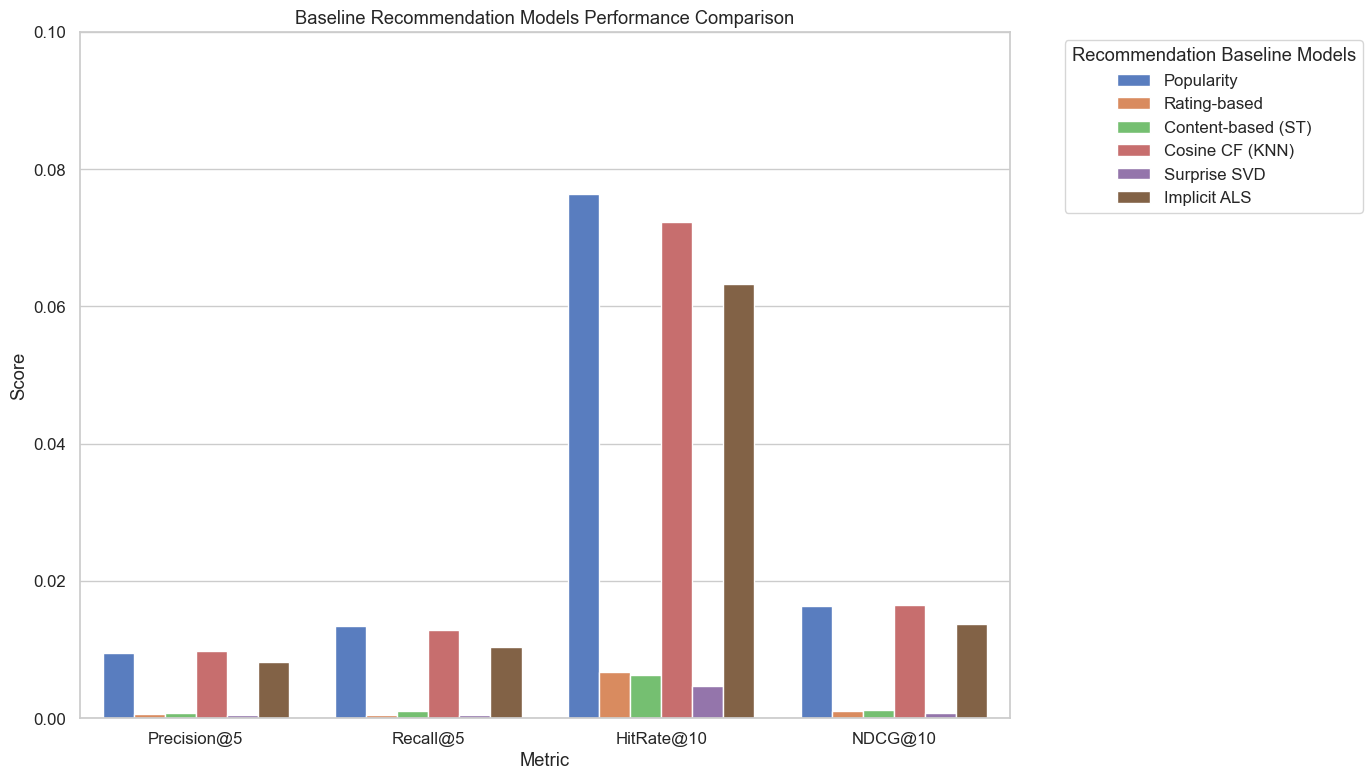

In [14]:
results_dir = project_root / 'RESULTS' / 'krina_week3'
results_dir.mkdir(parents=True, exist_ok=True)

models = ['Popularity', 'Rating-based', 'Content-based (ST)', 'Cosine CF (KNN)', 'Surprise SVD', 'Implicit ALS']
p5s = [pop_results[5]['precision'], rating_results[5]['precision'], content_results[5]['precision'], cosine_results[5]['precision'], svd_results[5]['precision'], als_results[5]['precision']]
r5s = [pop_results[5]['recall'], rating_results[5]['recall'], content_results[5]['recall'], cosine_results[5]['recall'], svd_results[5]['recall'], als_results[5]['recall']]
hr10s = [pop_results[10]['hitrate'], rating_results[10]['hitrate'], content_results[10]['hitrate'], cosine_results[10]['hitrate'], svd_results[10]['hitrate'], als_results[10]['hitrate']]
ndcg10s = [pop_results[10]['ndcg'], rating_results[10]['ndcg'], content_results[10]['ndcg'], cosine_results[10]['ndcg'], svd_results[10]['ndcg'], als_results[10]['ndcg']]

df_plot = pd.DataFrame({
    'Model': models * 4,
    'Metric Value': p5s + r5s + hr10s + ndcg10s,
    'Metric': ['Precision@5'] * 6 + ['Recall@5'] * 6 + ['HitRate@10'] * 6 + ['NDCG@10'] * 6
})

plt.figure(figsize=(14, 8))
sns.barplot(data=df_plot, x='Metric', y='Metric Value', hue='Model', palette='muted')
plt.title('Baseline Recommendation Models Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 0.1)
plt.legend(title='Recommendation Baseline Models', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
chart_path = results_dir / 'baselines_comparison.png'
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
print(f"Comparison chart saved to {chart_path}")
plt.show()